In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style("whitegrid")

In [8]:
# FILE_NAME = "product_detail_fixed.csv"
# FILE_NAME = "products_with_category_group.csv"
FILE_NAME = "category_group_price_tier_review.csv"

try:
    df = pd.read_csv(
        FILE_NAME,
        sep=',',
        engine='python',
        on_bad_lines='skip'
    )
except Exception as e:
    print(f"Lỗi khi tải file {FILE_NAME}: {e}")
    raise

# Xóa bỏ trùng lặp
df = df.drop_duplicates()

if df['discount_percent'].dtype == object:
    df['discount_percent_clean'] = (
        df['discount_percent']
        .str.replace('%', '', regex=False)
        .astype(float) / 100
    )
else:
    df['discount_percent_clean'] = df['discount_percent'] / 100

df['log_original_price'] = np.log10(df['original_price'] + 1)
df['log_sold'] = np.log10(df['sold'] + 1)

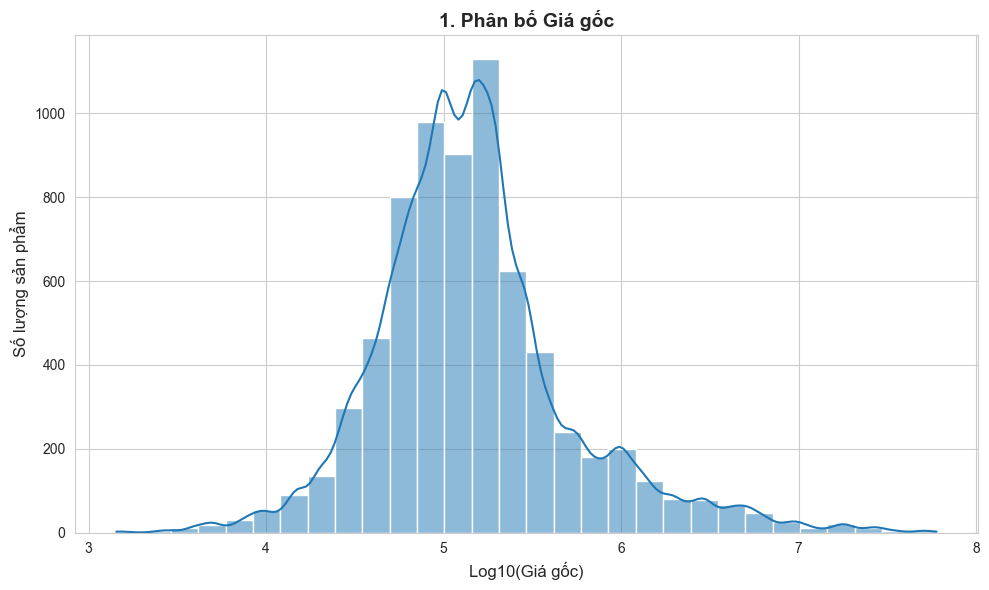

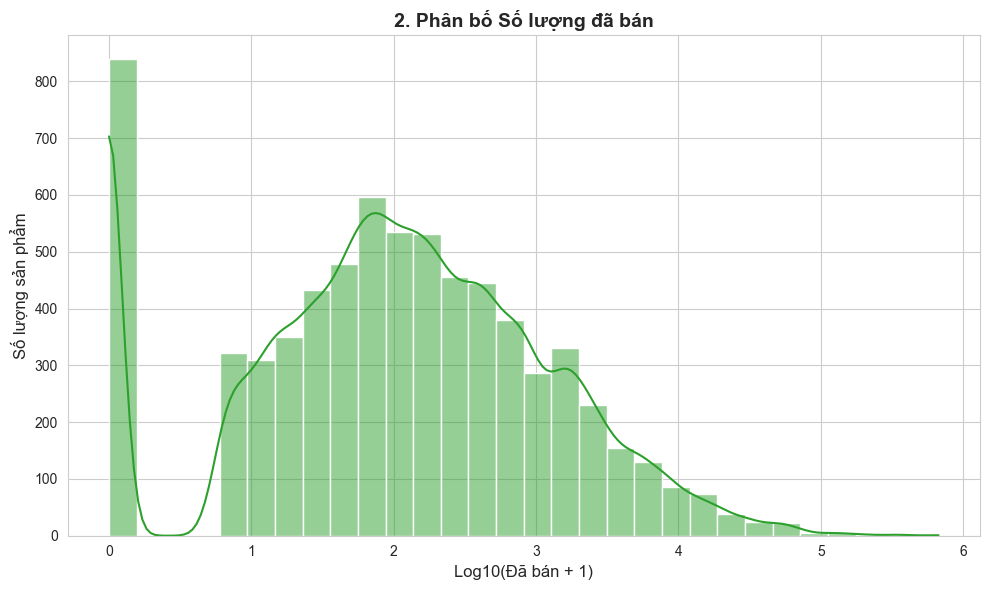

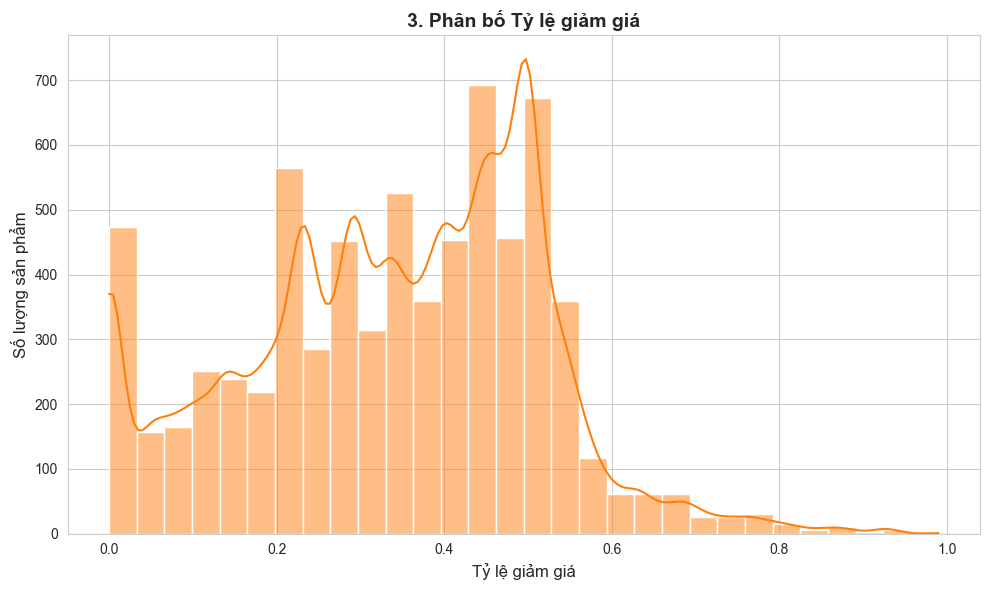

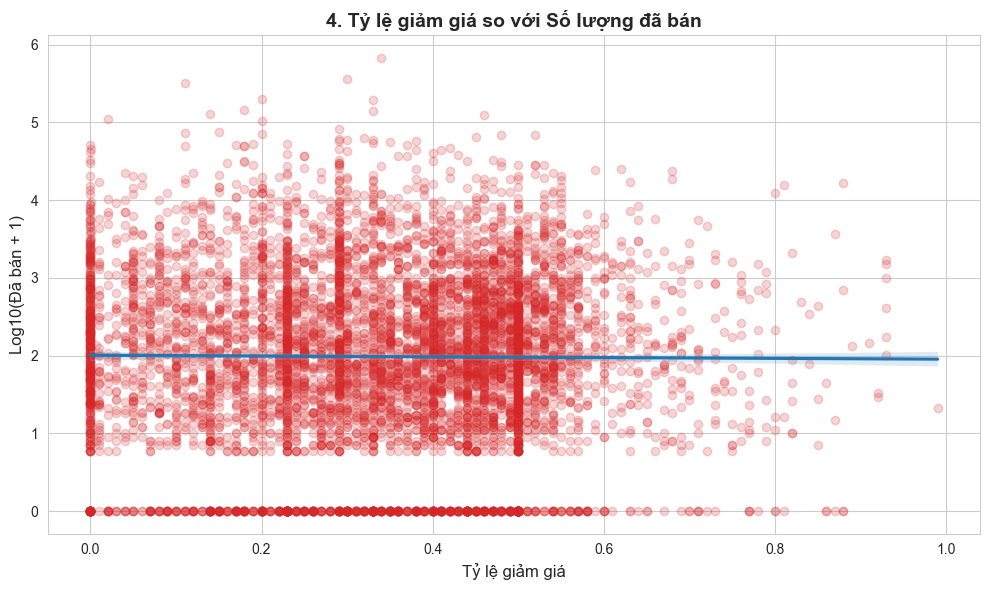

In [ ]:
# Biểu đồ 1: Phân bố Giá gốc (Log scale)
plt.figure(figsize=(10, 6))
sns.histplot(df['log_original_price'], bins=30, kde=True, kde_kws={'bw_adjust': 0.5}, color='#1f77b4')
plt.title('1. Phân bố Giá gốc', fontsize=14, fontweight='bold')
plt.xlabel('Log10(Giá gốc)', fontsize=12)
plt.ylabel('Số lượng sản phẩm', fontsize=12)
plt.tight_layout()
plt.savefig('chart_1_price_dist.png')

# Biểu đồ 2: Phân bố Số lượng bán (Log scale)
plt.figure(figsize=(10, 6))
sns.histplot(df['log_sold'], bins=30, kde=True, kde_kws={'bw_adjust': 0.5}, color='#2ca02c')
plt.title('2. Phân bố Số lượng đã bán', fontsize=14, fontweight='bold')
plt.xlabel('Log10(Đã bán + 1)', fontsize=12)
plt.ylabel('Số lượng sản phẩm', fontsize=12)
plt.tight_layout()
plt.savefig('chart_2_sold_dist.png')

# Biểu đồ 3: Phân bố Tỷ lệ giảm giá
plt.figure(figsize=(10, 6))
sns.histplot(df['discount_percent_clean'], bins=30, kde=True, kde_kws={'bw_adjust': 0.5}, color='#ff7f0e')
plt.title('3. Phân bố Tỷ lệ giảm giá', fontsize=14, fontweight='bold')
plt.xlabel('Tỷ lệ giảm giá', fontsize=12)
plt.ylabel('Số lượng sản phẩm', fontsize=12)
plt.tight_layout()
plt.savefig('chart_3_discount_dist.png')

# Biểu đồ 4: Mối quan hệ giữa Tỷ lệ giảm giá và Số lượng bán
plt.figure(figsize=(10, 6))
sns.regplot(
    x='discount_percent_clean',
    y='log_sold',
    data=df,
    scatter_kws={'alpha':0.2, 'color':'#d62728'},
    line_kws={'color':'#1f77b4'}
)
plt.title('4. Tỷ lệ giảm giá so với Số lượng đã bán', fontsize=14, fontweight='bold')
plt.xlabel('Tỷ lệ giảm giá', fontsize=12)
plt.ylabel('Log10(Đã bán + 1)', fontsize=12)
plt.tight_layout()
plt.savefig('chart_4_discount_vs_sold.png')

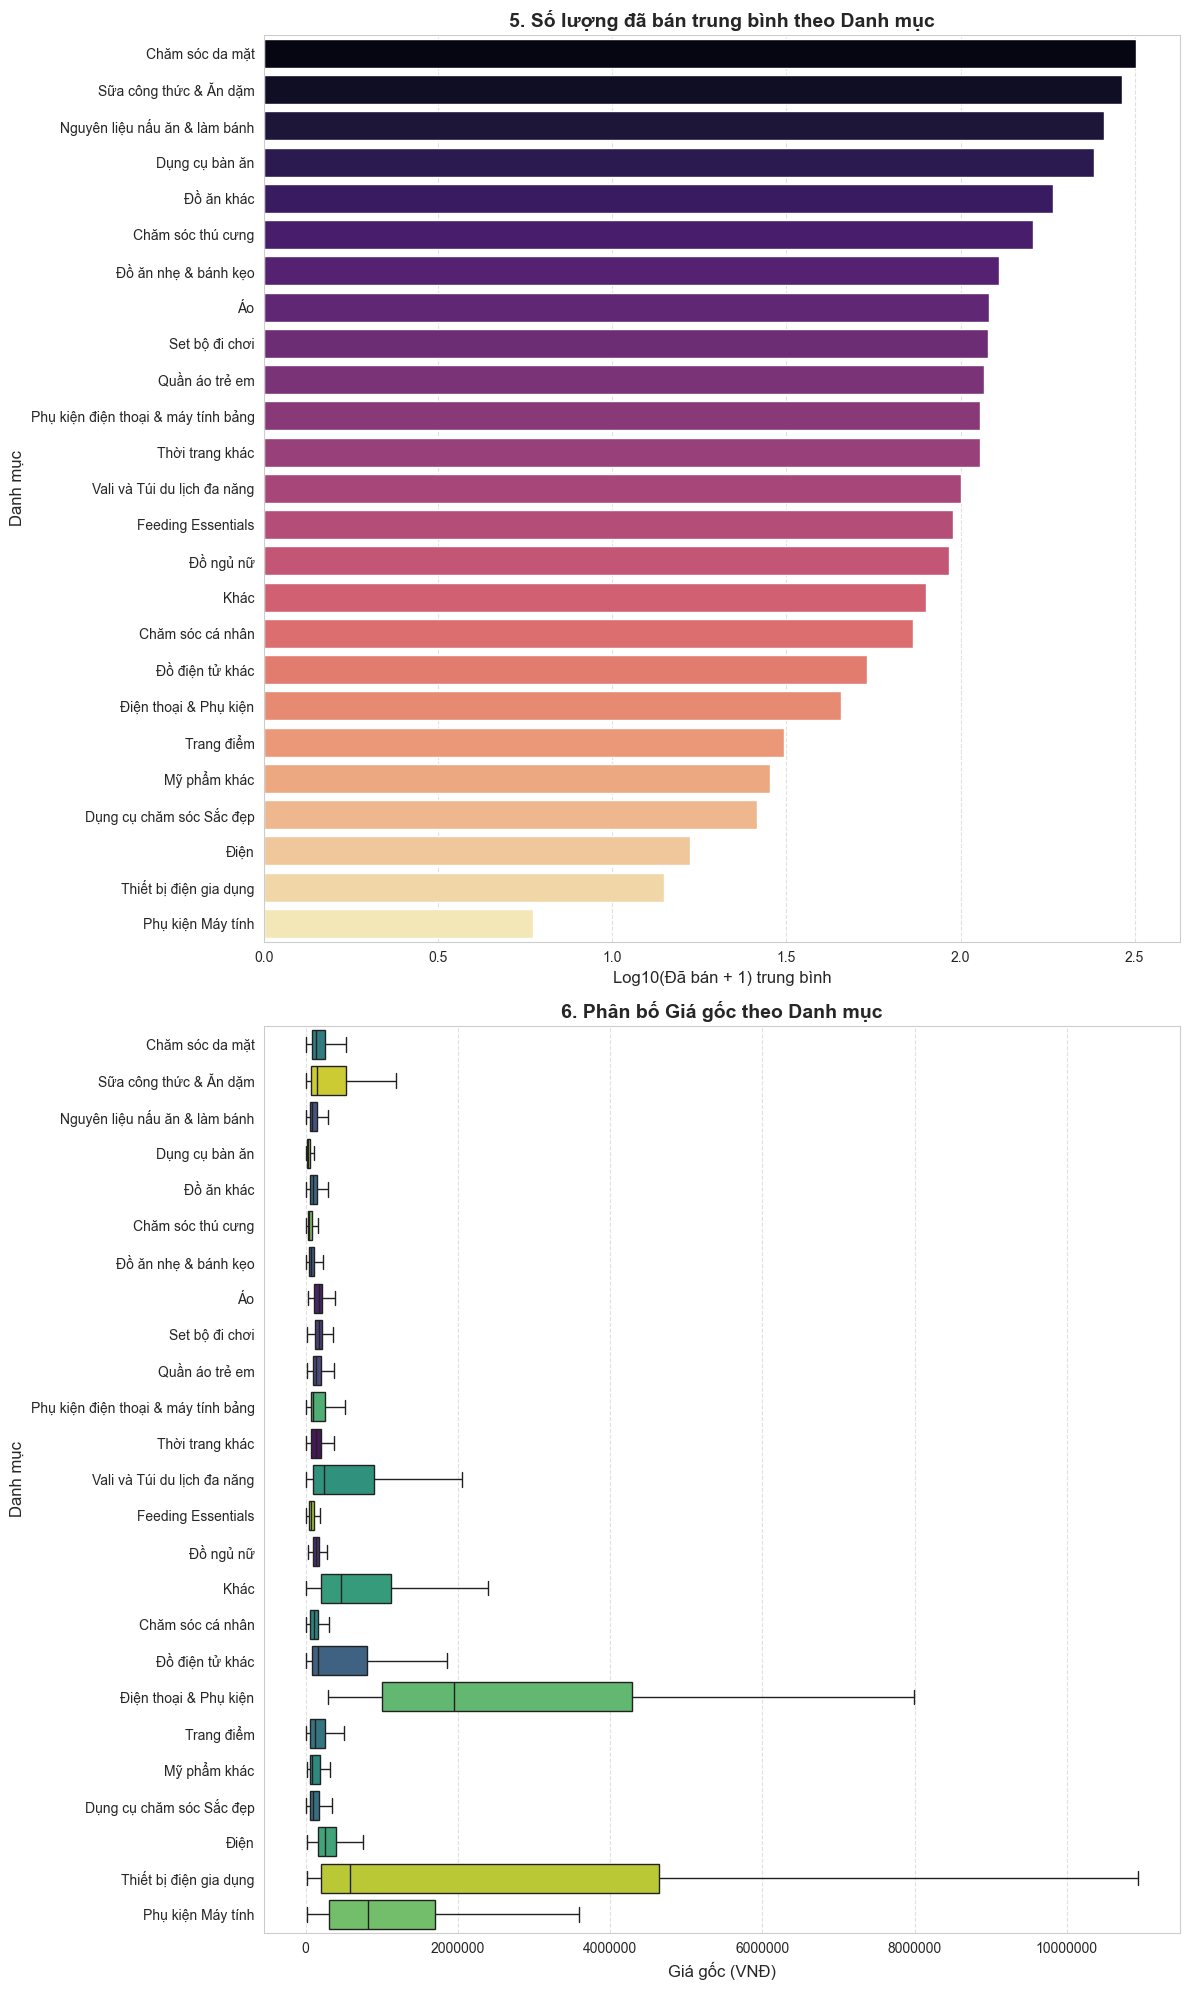

In [ ]:
all_categories = df['category_group'].unique()
chart_height = max(7, len(all_categories) * 0.4)

category_sales = df.groupby('category_group')['log_sold'].mean().sort_values(ascending=False).reset_index()
category_order = category_sales['category_group'].tolist()

# Biểu đồ 5: Số lượng đã bán trung bình theo Danh mục
plt.figure(figsize=(10, chart_height))
sns.barplot(
    x='log_sold',
    y='category_group',
    data=category_sales,
    hue='category_group',
    palette='magma',
    order=category_order
)
plt.legend([],[], frameon=False)
plt.title('5. Số lượng đã bán trung bình theo Danh mục', fontsize=14, fontweight='bold')
plt.xlabel('Log10(Đã bán + 1) trung bình', fontsize=12)
plt.ylabel('Danh mục', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('chart_sales_avg.png')

# Biểu đồ 6: Phân bố Giá gốc theo Danh mục
plt.figure(figsize=(10, chart_height))
sns.boxplot(
    x='original_price',
    y='category_group',
    data=df,
    hue='category_group',
    order=category_order,
    palette='viridis',
    showfliers=False 
)
plt.legend([],[], frameon=False)
plt.title('6. Phân bố Giá gốc theo Danh mục', fontsize=14, fontweight='bold')
plt.xlabel('Giá gốc (VNĐ)', fontsize=12)
plt.ylabel('Danh mục', fontsize=12)
plt.ticklabel_format(style='plain', axis='x') 
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('chart_price_dist.png')

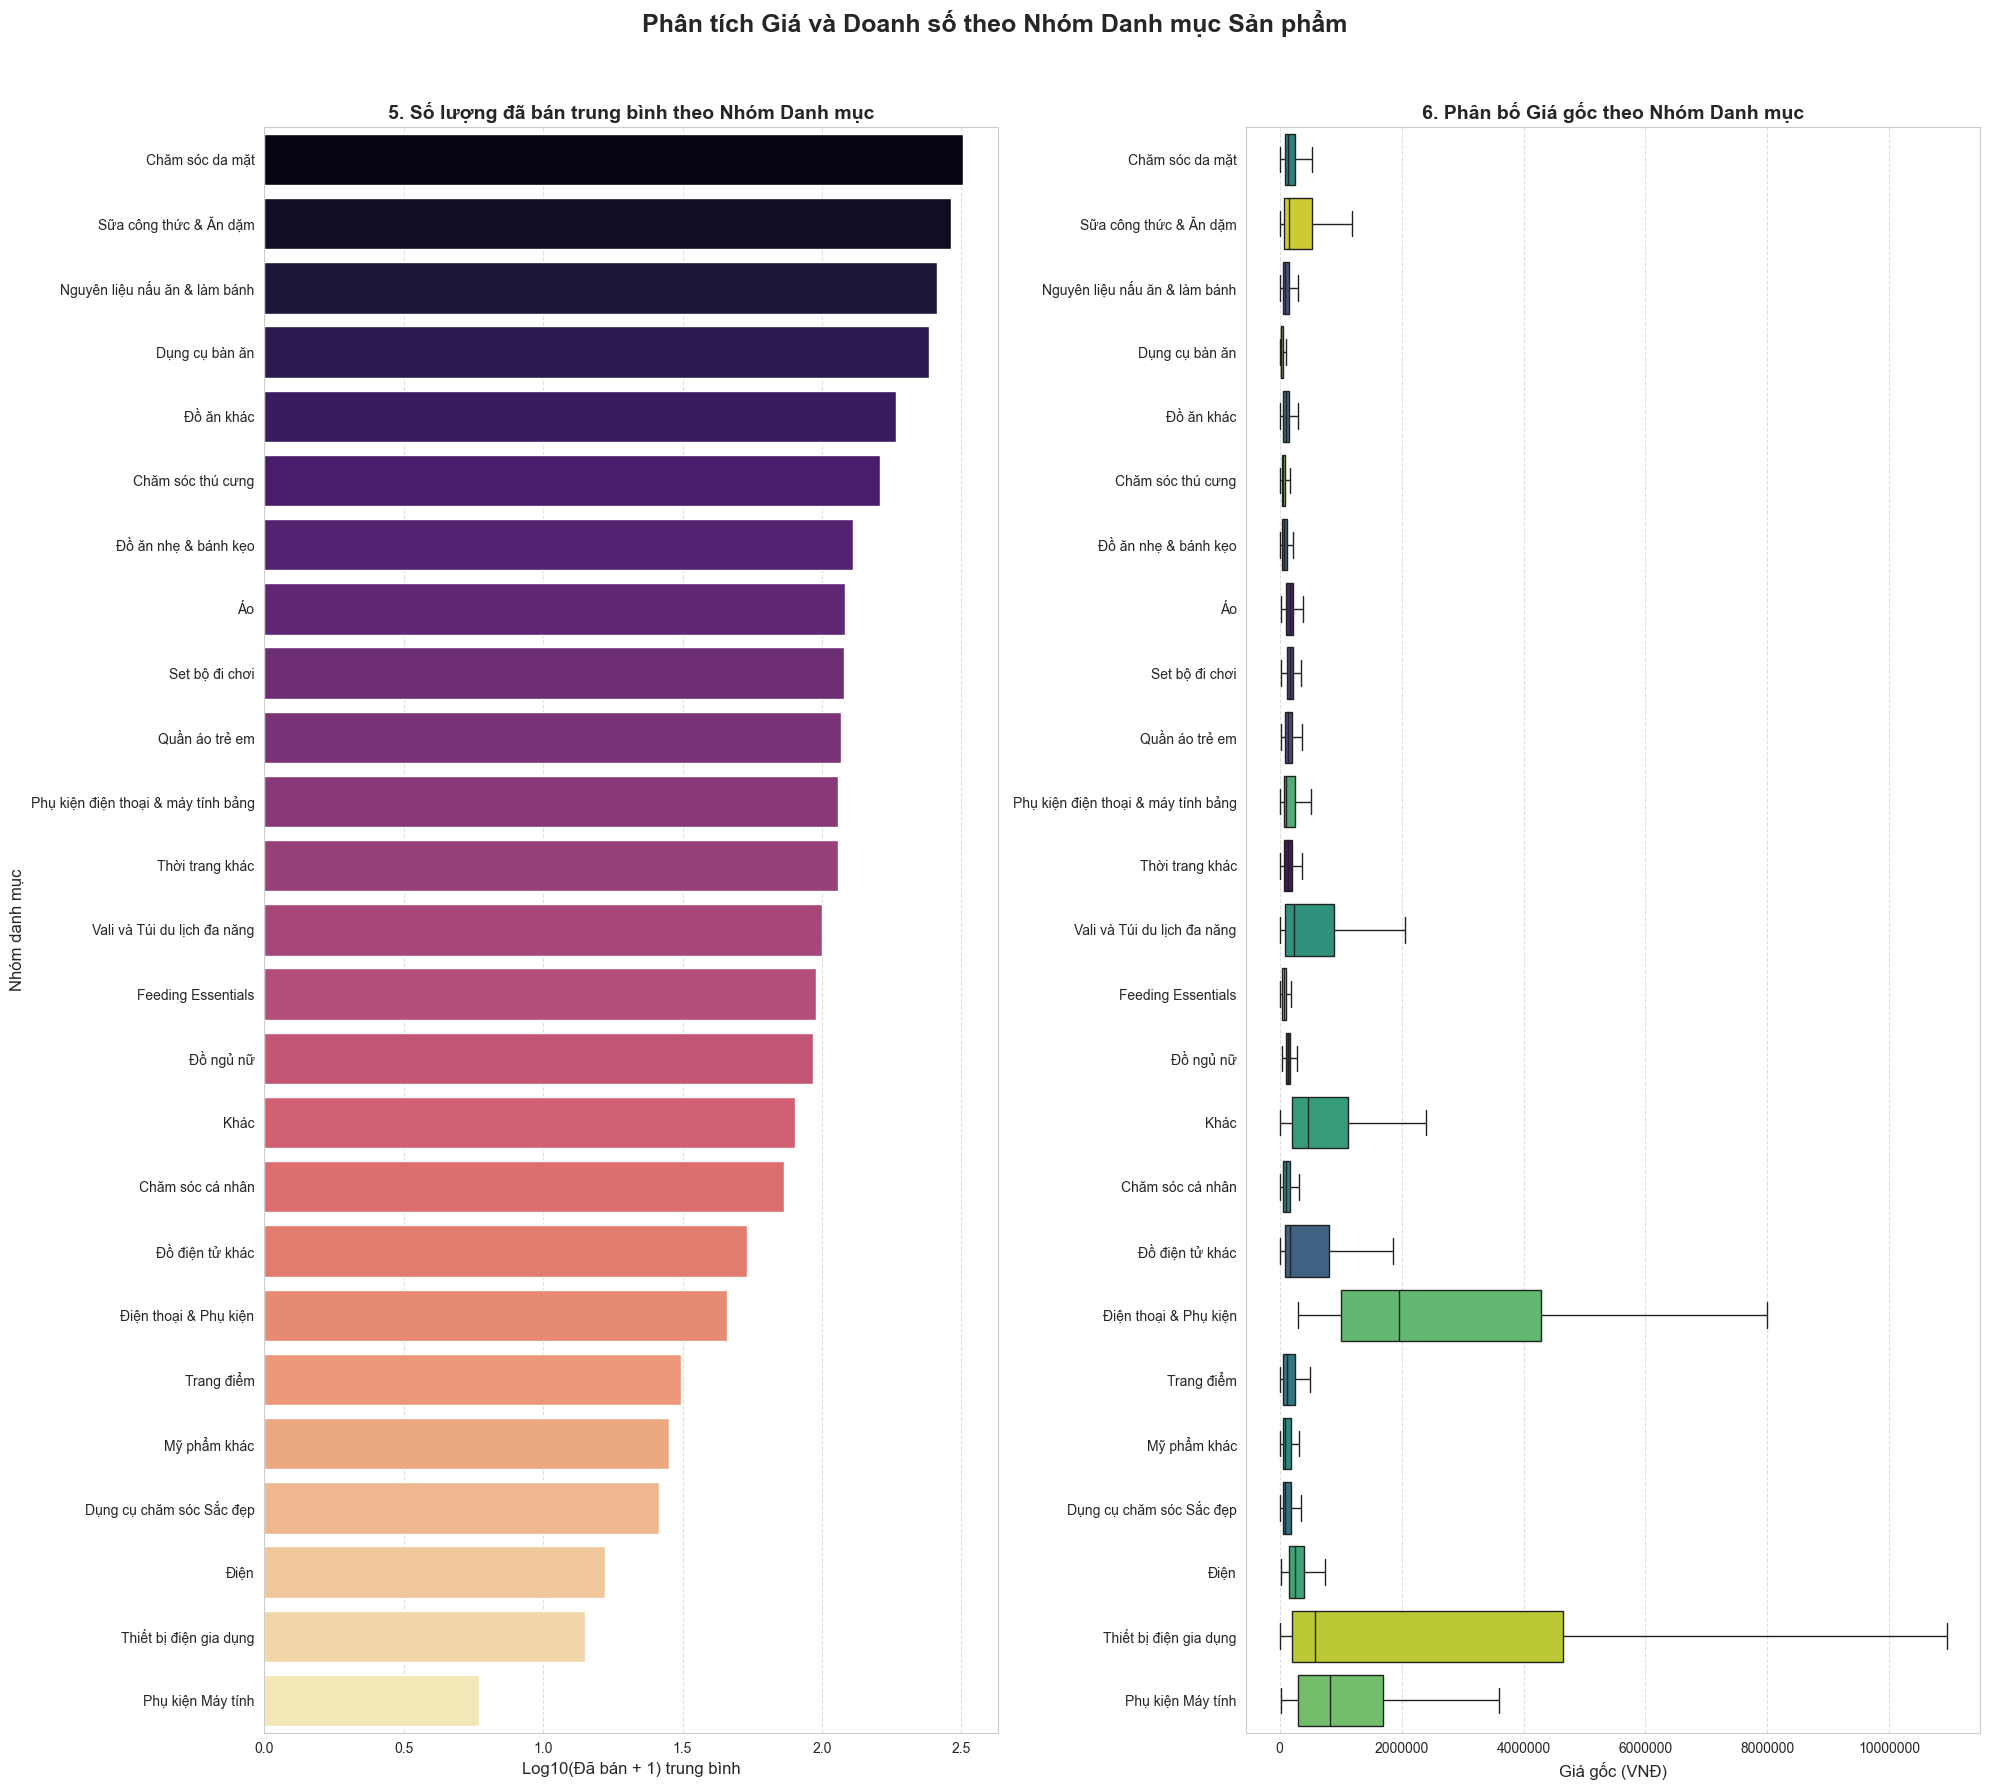

In [11]:
FILE_NAME = "product_detail_fixed.csv"
try:
    df = pd.read_csv(
        FILE_NAME,
        sep=',',
        engine='python',
        on_bad_lines='skip'
    )
except Exception as e:
    print(f"Lỗi khi tải file {FILE_NAME}: {e}")
    raise

# Xóa bỏ trùng lặp
df = df.drop_duplicates()

if df['discount_percent'].dtype == object:
    df['discount_percent_clean'] = (
        df['discount_percent']
        .str.replace('%', '', regex=False)
        .astype(float) / 100
    )
else:
    df['discount_percent_clean'] = df['discount_percent'] / 100

df['log_original_price'] = np.log10(df['original_price'] + 1)
df['log_sold'] = np.log10(df['sold'] + 1)

# Figure 2: Phân tích theo Danh mục (Biểu đồ 5, 6)

# Sắp xếp thứ tự dựa trên hiệu suất bán hàng (log_sold) trung bình
category_sales = df.groupby('category_group')['log_sold'].mean().sort_values(ascending=False).reset_index()
category_order = category_sales['category_group'].tolist()

# Tính toán chiều cao biểu đồ dựa trên số lượng nhóm (giúp biểu đồ giãn ra nếu nhiều danh mục)
num_groups = len(category_order)
dynamic_height = max(7, num_groups * 0.7) 

fig, axes = plt.subplots(1, 2, figsize=(20, dynamic_height))

# Biểu đồ 5: Log(Số lượng đã bán) trung bình theo Nhóm Danh mục (Bar Plot)
sns.barplot(
    x='log_sold',
    y='category_group',
    data=category_sales,
    ax=axes[0],
    hue='category_group',         
    palette='magma',
    order=category_order,
    legend=False      
)
axes[0].set_title('5. Số lượng đã bán trung bình theo Nhóm Danh mục', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Log10(Đã bán + 1) trung bình', fontsize=12)
axes[0].set_ylabel('Nhóm danh mục', fontsize=12)
axes[0].grid(axis='x', linestyle='--', alpha=0.6)

# Biểu đồ 6: Phân bố Giá gốc theo Nhóm Danh mục (Box Plot)
sns.boxplot(
    x='original_price',
    y='category_group',
    data=df, # Sử dụng toàn bộ df
    hue='category_group',         
    order=category_order,
    ax=axes[1],
    palette='viridis',
    legend=False,         
    showfliers=False 
)
axes[1].set_title('6. Phân bố Giá gốc theo Nhóm Danh mục', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Giá gốc (VNĐ)', fontsize=12)
axes[1].set_ylabel('', fontsize=12)
axes[1].ticklabel_format(style='plain', axis='x')
axes[1].grid(axis='x', linestyle='--', alpha=0.6)

plt.suptitle('Phân tích Giá và Doanh số theo Nhóm Danh mục Sản phẩm', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_charts_all_categories.png')


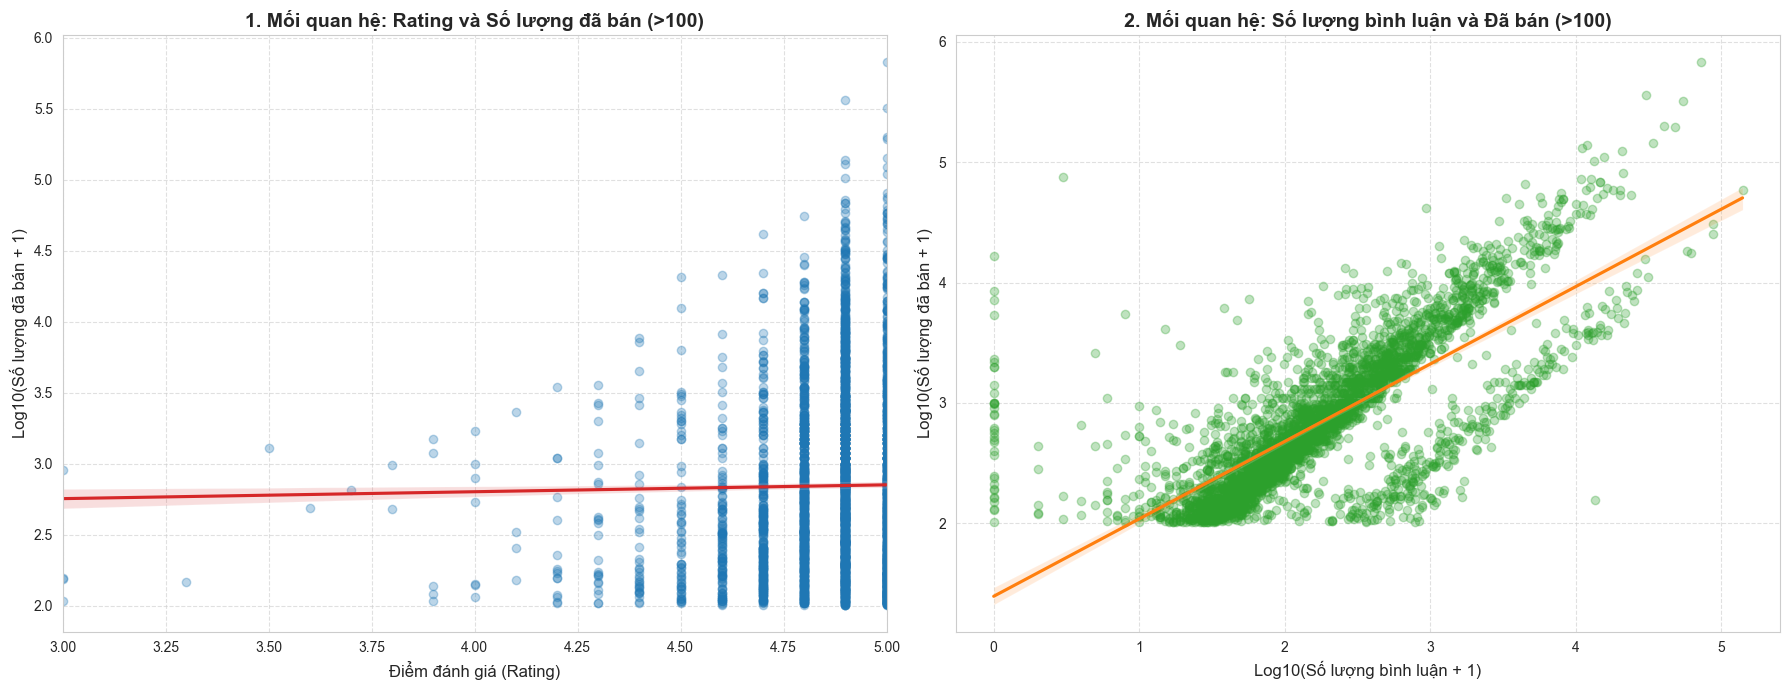

In [ ]:
# Tiền xử lý dữ liệu
df_filtered = df[df['sold'] > 100].copy()
df_filtered['log_comment_count'] = np.log10(df_filtered['comment_count'] + 1)

# BIỂU ĐỒ 1: Rating vs Sold
plt.figure(figsize=(10, 7))
sns.regplot(
    x='rating',
    y='log_sold',
    data=df_filtered,
    scatter_kws={'alpha':0.3, 'color':'#1f77b4'},
    line_kws={'color':'#d62728'}
)
plt.title('Mối quan hệ: Điểm đánh giá (Rating) và Số lượng đã bán (>100)', fontsize=14, fontweight='bold')
plt.xlabel('Điểm đánh giá (Rating)', fontsize=12)
plt.ylabel('Log10(Số lượng đã bán + 1)', fontsize=12)
plt.grid(axis='both', linestyle='--', alpha=0.6)
plt.xlim(3.0, 5.0)
plt.tight_layout()
plt.savefig('1_sold_vs_rating.png') 
plt.show()

# BIỂU ĐỒ 2: Comment vs Sold 
plt.figure(figsize=(10, 7))
sns.regplot(
    x='log_comment_count',
    y='log_sold',
    data=df_filtered,
    scatter_kws={'alpha':0.3, 'color':'#2ca02c'},
    line_kws={'color':'#ff7f0e'}
)
plt.title('Mối quan hệ: Số lượng bình luận và Số lượng đã bán (>100)', fontsize=14, fontweight='bold')
plt.xlabel('Log10(Số lượng bình luận + 1)', fontsize=12)
plt.ylabel('Log10(Số lượng đã bán + 1)', fontsize=12)
plt.grid(axis='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('2_sold_vs_comment.png') 
plt.show()